# Fraud Detection Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(r"C:\Users\gulbu\Downloads\Fraud Detection Dataset.csv")
df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


In [11]:
# Transaction_ID: Unique identifier for the transaction
# User_ID: Unique identifier for the user
# Transaction_Amount: The monetary value of the transaction
# Transaction_Type: The category or type of transaction
# Time_of_Transaction: Timestamp of when the transaction occurred
# Device_Used: The specific device used for the transaction
# Location: Geographical location of the transaction
# Previous_Fraudulent_Transactions: Total count of the user's past fraudulent activities
# Account_Age: Age of the user's account
# Number_of_Transactions_Last_24H: Total number of transactions in the past 24 hours
# Payment_Method: The method used to complete the payment
# Fraudulent: Target variable indicating whether the transaction is fraud or not

## Data Cleaning

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [13]:
#Transaction_Amount, Time_of_Transaction, Device_Used, Location, Payment_Method have null values.

In [15]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [16]:
df.nunique()

Transaction_ID                      50000
User_ID                              4000
Transaction_Amount                  44821
Transaction_Type                        5
Time_of_Transaction                    24
Device_Used                             4
Location                                8
Previous_Fraudulent_Transactions        5
Account_Age                           119
Number_of_Transactions_Last_24H        14
Payment_Method                          5
Fraudulent                              2
dtype: int64

In [18]:
df = df.drop_duplicates()
df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50964,T44427,1830,4187.49,Bank Transfer,4.0,Mobile,Chicago,2,67,13,NaN,0
50975,T44680,4877,1826.49,POS Payment,10.0,Desktop,Houston,1,91,4,Net Banking,0
50985,T39758,2029,544.53,Bank Transfer,14.0,Unknown Device,Chicago,4,59,12,Debit Card,0
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0


In [20]:
df.shape

(50119, 12)

In [21]:
#missing value handling
df["Transaction_Amount"].fillna(df["Transaction_Amount"].median(), inplace = True)
df["Time_of_Transaction"].fillna(df["Time_of_Transaction"].mode()[0], inplace=True)
df["Device_Used"].fillna(df["Device_Used"].mode()[0], inplace=True)
df["Location"].fillna("Unknown", inplace=True)
df["Payment_Method"].fillna(df["Payment_Method"].mode()[0], inplace=True)

C:\Users\gulbu\AppData\Local\Temp\ipykernel_9996\1290724881.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Transaction_Amount"].fillna(df["Transaction_Amount"].median(), inplace = True)
C:\Users\gulbu\AppData\Local\Temp\ipykernel_9996\1290724881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Transaction_Amount"].fillna(df["Tr

In [22]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [23]:
#data type control
df["User_ID"] = df["User_ID"].astype(str)
df["Time_of_Transaction"] = df["Time_of_Transaction"].astype(int)

C:\Users\gulbu\AppData\Local\Temp\ipykernel_9996\4123263182.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["User_ID"] = df["User_ID"].astype(str)
C:\Users\gulbu\AppData\Local\Temp\ipykernel_9996\4123263182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Time_of_Transaction"] = df["Time_of_Transaction"].astype(int)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50119 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    50119 non-null  object 
 1   User_ID                           50119 non-null  object 
 2   Transaction_Amount                50119 non-null  float64
 3   Transaction_Type                  50119 non-null  object 
 4   Time_of_Transaction               50119 non-null  int32  
 5   Device_Used                       50119 non-null  object 
 6   Location                          50119 non-null  object 
 7   Previous_Fraudulent_Transactions  50119 non-null  int64  
 8   Account_Age                       50119 non-null  int64  
 9   Number_of_Transactions_Last_24H   50119 non-null  int64  
 10  Payment_Method                    50119 non-null  object 
 11  Fraudulent                        50119 non-null  int64  
dtypes: float6

In [29]:
df.head(100)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,18,Mobile,Unknown,3,115,9,UPI,0
3,T4,2294,100.10,Bill Payment,15,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15,Desktop,Boston,3,96,14,Credit Card,0
6,T7,4772,544.81,Bill Payment,2,Tablet,Boston,3,6,9,UPI,1
7,T8,4092,635.75,ATM Withdrawal,13,Tablet,Boston,2,13,10,Debit Card,0
8,T9,2638,2318.87,Bank Transfer,18,Mobile,San Francisco,4,110,12,Debit Card,0
9,T10,3169,3656.17,Bill Payment,3,Mobile,Chicago,4,66,3,Net Banking,0


In [39]:
df[df["Transaction_Amount"] < 0]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [40]:
df[(df["Time_of_Transaction"] < 0) | (df["Time_of_Transaction"] > 23)]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [41]:
df[df["Previous_Fraudulent_Transactions"] < 0]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [42]:
df[df["Account_Age"] < 0]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [43]:
df[df["Number_of_Transactions_Last_24H"] < 0]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [44]:
df["Fraudulent"].unique()

array([0, 1], dtype=int64)

## EDA

In [45]:
#Unique values of categorical columns
print(df["Transaction_Type"].unique())
print(df["Device_Used"].unique())
print(df["Location"].unique())
print(df["Payment_Method"].unique())

['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
['Tablet' 'Mobile' 'Desktop' 'Unknown Device']
['San Francisco' 'New York' 'Unknown' 'Chicago' 'Boston' 'Houston' 'Miami'
 'Los Angeles' 'Seattle']
['Debit Card' 'Credit Card' 'UPI' 'Net Banking' 'Invalid Method']


In [46]:
df.describe()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,50119.000000,50119.000000,50119.000000,50119.000000,50119.000000,50119.000000
mean,2975.612532,11.814023,1.996448,60.029071,7.495640,0.049223
std,4935.678196,6.893661,1.415492,34.392569,4.019806,0.216335
min,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1333.370000,6.000000,1.000000,30.000000,4.000000,0.000000
50%,2523.580000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,3721.755000,18.000000,3.000000,90.000000,11.000000,0.000000
max,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [48]:
#Fraud Rate Analysis
#Business Problem: What is the rate of fraud among all transactions?
#Fraud Rate = Fraudulent Transactions / Total Transactions

df["Fraudulent"].value_counts()

Fraudulent
0    47652
1     2467
Name: count, dtype: int64

In [50]:
fraud_rate = df["Fraudulent"].mean() * 100
print("Fraud Rate:", fraud_rate)

Fraud Rate: 4.922284961790938


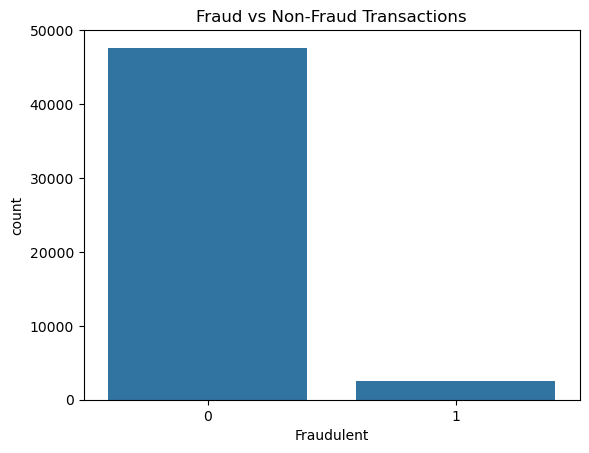

In [51]:
sns.countplot(x= "Fraudulent", data = df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [87]:
#Comment: The fraud rate in the dataset is approximately 4.9%, indicating that a small portion of transactions are fraudulent. 
#This imbalance is typical in financial datasets and highlights the importance of identifying patterns that distinguish fraudulent transactions from legitimate ones.

In [52]:
#Transaction Amount Analysis
#Business Problem: Are the fraud transactions high-value?

In [53]:
df.groupby("Fraudulent")["Transaction_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,47652.0,2969.287066,4901.345884,5.03,1334.6625,2523.58,3726.0175,49997.8
1,2467.0,3097.793758,5557.073909,14.31,1312.9350,2523.58,3659.0300,49997.8


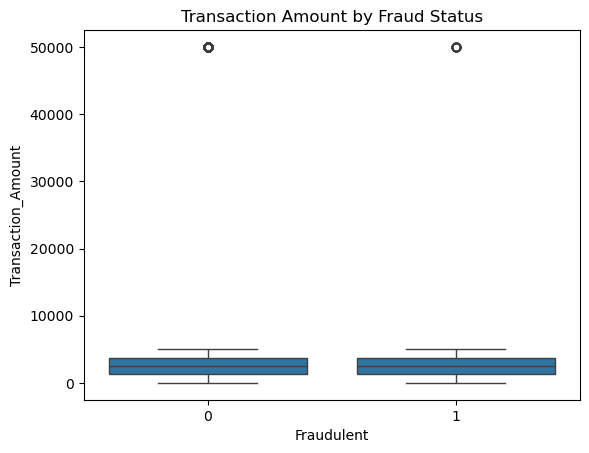

In [54]:
sns.boxplot(x="Fraudulent", y="Transaction_Amount", data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()

In [88]:
#Comment: The boxplot analysis shows that fraudulent transactions do not necessarily involve higher transaction amounts. 
#The median transaction value is relatively similar between fraudulent and non-fraudulent transactions, indicating that fraud can occur across various transaction sizes.

In [55]:
#Time Pattern Analysis
#Business Problem: At what times of day are fraud transactions most frequent?

In [57]:
fraud_by_hour = df.groupby("Time_of_Transaction")["Fraudulent"].mean()
fraud_by_hour

Time_of_Transaction
0     0.045703
1     0.048096
2     0.051243
3     0.046960
4     0.048719
5     0.044701
6     0.051856
7     0.054844
8     0.047094
9     0.043365
10    0.047077
11    0.047071
12    0.045128
13    0.046409
14    0.045244
15    0.057561
16    0.047737
17    0.050495
18    0.052448
19    0.046073
20    0.056174
21    0.042607
22    0.057741
23    0.052604
Name: Fraudulent, dtype: float64

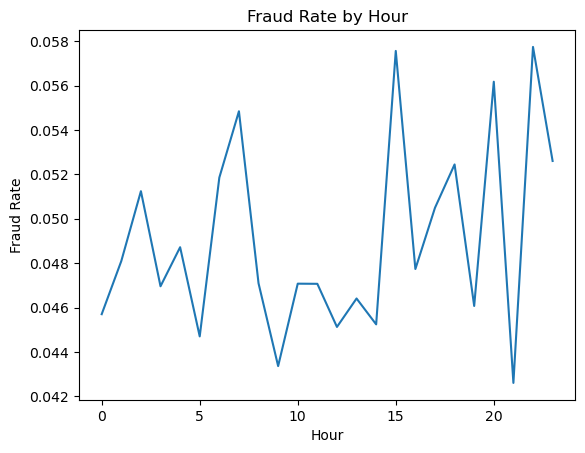

In [58]:
fraud_by_hour.plot(kind="line")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

In [94]:
#Comment: The fraud rate remains relatively stable throughout the day, fluctuating between approximately 4.3% and 5.8%.

In [59]:
#Device Risk Analysis
#Business Problem: Which devices are riskier for fraud?

In [60]:
device_fraud = df.groupby("Device_Used")["Fraudulent"].mean().sort_values(ascending=False)
print(device_fraud)

Device_Used
Mobile            0.051628
Desktop           0.049385
Unknown Device    0.049020
Tablet            0.046645
Name: Fraudulent, dtype: float64


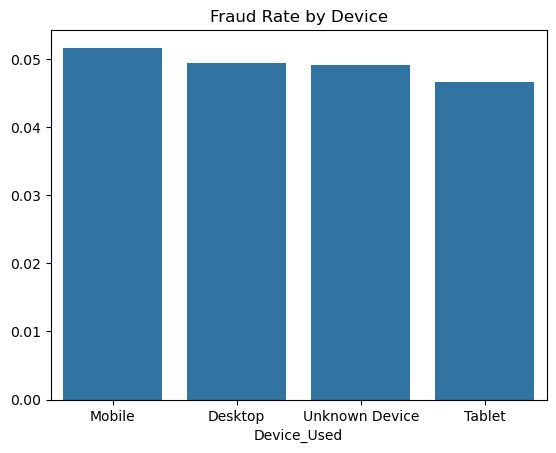

In [61]:
sns.barplot(x=device_fraud.index, y=device_fraud.values)
plt.title("Fraud Rate by Device")
plt.show()

In [89]:
#Comment: The analysis shows that mobile devices account for the highest share of fraudulent transactions. 
#This may be due to the widespread use of mobile devices and the potential security vulnerabilities associated with mobile networks.

In [62]:
#Payment Method Risk
#Business Problem: Which payment methods are riskier?

In [63]:
payment_fraud = df.groupby("Payment_Method")["Fraudulent"].mean().sort_values(ascending=False)
print(payment_fraud)

Payment_Method
UPI               0.049578
Credit Card       0.049225
Debit Card        0.049165
Net Banking       0.049032
Invalid Method    0.047806
Name: Fraudulent, dtype: float64


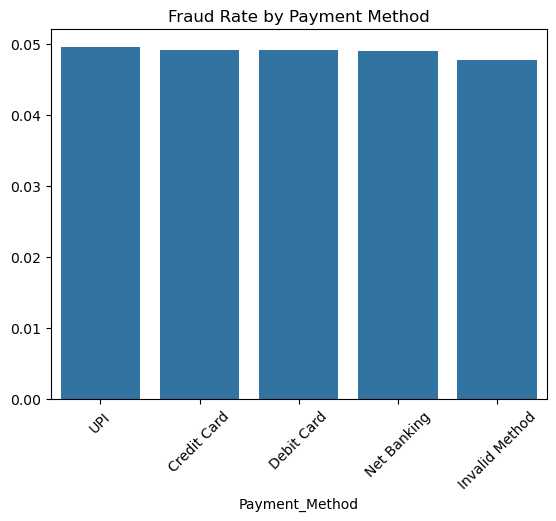

In [64]:
sns.barplot(x=payment_fraud.index, y=payment_fraud.values)
plt.title("Fraud Rate by Payment Method")
plt.xticks(rotation=45)
plt.show()

In [90]:
#Comment: UPI transactions show the highest fraud rate, although the difference between payment methods is relatively small. 
#This suggests that fraud risk is distributed across multiple payment channels rather than concentrated in a single payment method.

In [65]:
#Transaction Type Analysis
#Business Problem: Which transaction types are riskier in terms of fraud?

In [66]:
transaction_type_fraud = df.groupby("Transaction_Type")["Fraudulent"].mean().sort_values(ascending=False)
print(transaction_type_fraud)

Transaction_Type
Online Purchase    0.051352
POS Payment        0.050115
Bill Payment       0.049798
Bank Transfer      0.048170
ATM Withdrawal     0.046698
Name: Fraudulent, dtype: float64


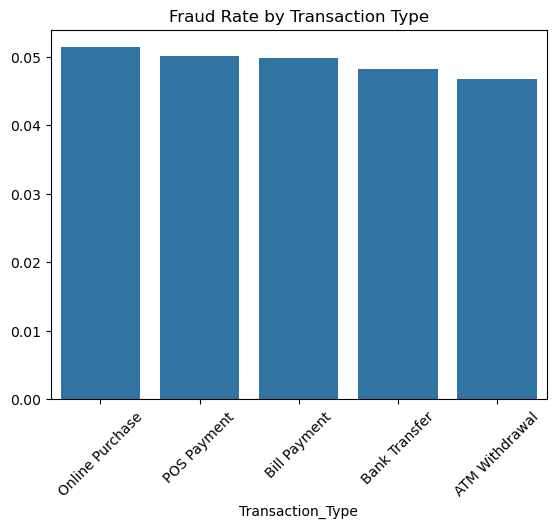

In [69]:
sns.barplot(x=transaction_type_fraud.index, y=transaction_type_fraud.values)
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation=45)
plt.show()

In [91]:
#Comment: Online purchases appear to have the highest fraud rate. 
#This is consistent with real-world financial fraud patterns where online transactions are more vulnerable due to the lack of physical authentication.

In [70]:
#Location Risk Analysis
#Business Problem: Are fraud transactions concentrated in specific locations?

In [71]:
location_fraud = df.groupby("Location")["Fraudulent"].mean().sort_values(ascending=False)
print(location_fraud.head(10))

Location
Chicago          0.055127
Los Angeles      0.051607
Boston           0.050025
San Francisco    0.049991
Miami            0.049796
Unknown          0.048800
New York         0.047476
Houston          0.046672
Seattle          0.043326
Name: Fraudulent, dtype: float64


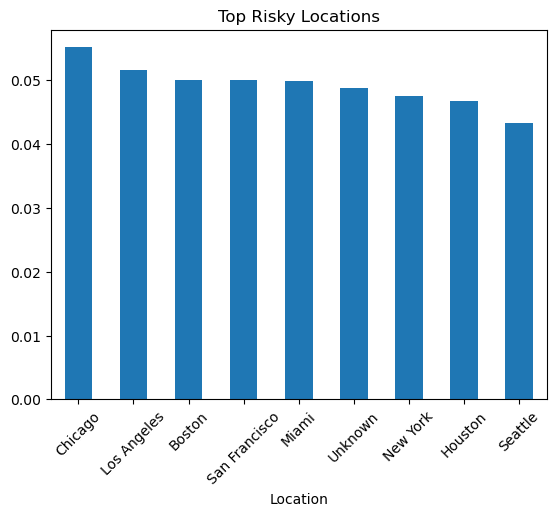

In [72]:
location_fraud.head(10).plot(kind="bar")
plt.title("Top Risky Locations")
plt.xticks(rotation=45)
plt.show()

In [92]:
#Comment: The location analysis indicates that Chicago has the highest number of fraudulent transactions. 
#This may suggest geographic fraud concentration or targeted fraudulent activity in specific regions.

In [73]:
#Account Age Analysis
#Business Problem: Are new accounts or old accounts riskier?

In [74]:
df.groupby("Fraudulent")["Account_Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,47652.0,59.985898,34.381256,1.0,30.0,60.0,90.0,119.0
1,2467.0,60.862991,34.606815,1.0,32.0,62.0,91.0,119.0


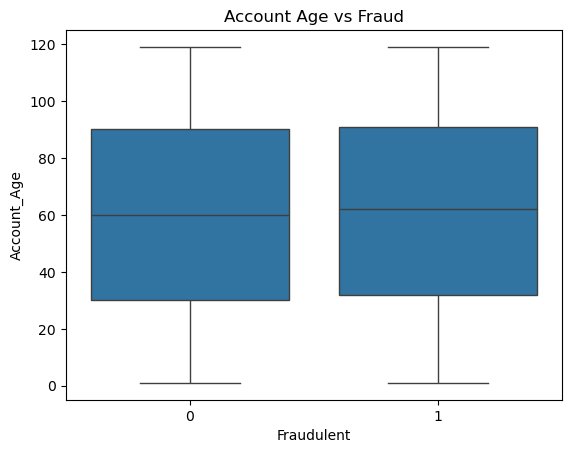

In [75]:
sns.boxplot(x="Fraudulent", y="Account_Age", data=df)
plt.title("Account Age vs Fraud")
plt.show()

In [76]:
#Transaction Frequency Analysis
#Business Problem: Are users who transacted a lot in the last 24 hours riskier?

In [77]:
df.groupby("Fraudulent")["Number_of_Transactions_Last_24H"].describe()

,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,47652.0,7.499266,4.020605,1.0,4.0,7.0,11.0,14.0
1,2467.0,7.425618,4.004514,1.0,4.0,7.0,11.0,14.0


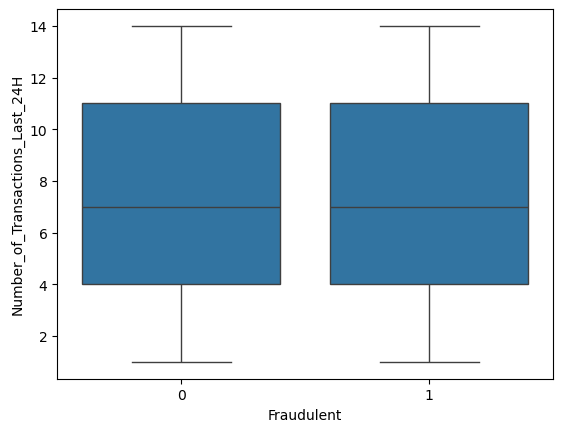

In [78]:
sns.boxplot(x="Fraudulent", y="Number_of_Transactions_Last_24H", data=df)
plt.show()

In [79]:
#Previous Fraud Behavior
#Business Problem: Are users who committed fraud in the past committing fraud again?

In [80]:
df.groupby("Previous_Fraudulent_Transactions")["Fraudulent"].mean()

Previous_Fraudulent_Transactions
0    0.047025
1    0.050924
2    0.050193
3    0.049889
4    0.048112
Name: Fraudulent, dtype: float64

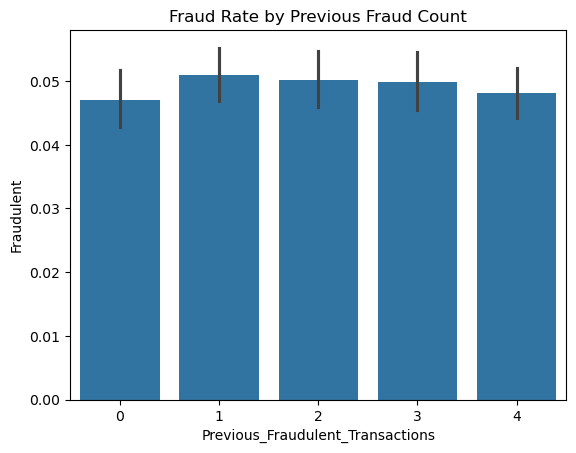

In [81]:
sns.barplot(
    x="Previous_Fraudulent_Transactions",
    y="Fraudulent",
    data=df
)
plt.title("Fraud Rate by Previous Fraud Count")
plt.show()

In [93]:
#Comment: Users who previously committed fraudulent transactions appear more likely to engage in fraud again. 
#This highlights the importance of monitoring accounts with a history of suspicious activity.

In [83]:
#Correlation Analysis
corr = df.corr(numeric_only = True)
corr

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
Transaction_Amount,1.000000,-0.006575,-0.001469,0.002932,-0.004251,0.005633
Time_of_Transaction,-0.006575,1.000000,-0.004697,-0.001595,-0.009490,0.006245
Previous_Fraudulent_Transactions,-0.001469,-0.004697,1.000000,0.000875,-0.000736,0.000766
Account_Age,0.002932,-0.001595,0.000875,1.000000,0.004506,0.005517
Number_of_Transactions_Last_24H,-0.004251,-0.009490,-0.000736,0.004506,1.000000,-0.003964
Fraudulent,0.005633,0.006245,0.000766,0.005517,-0.003964,1.000000


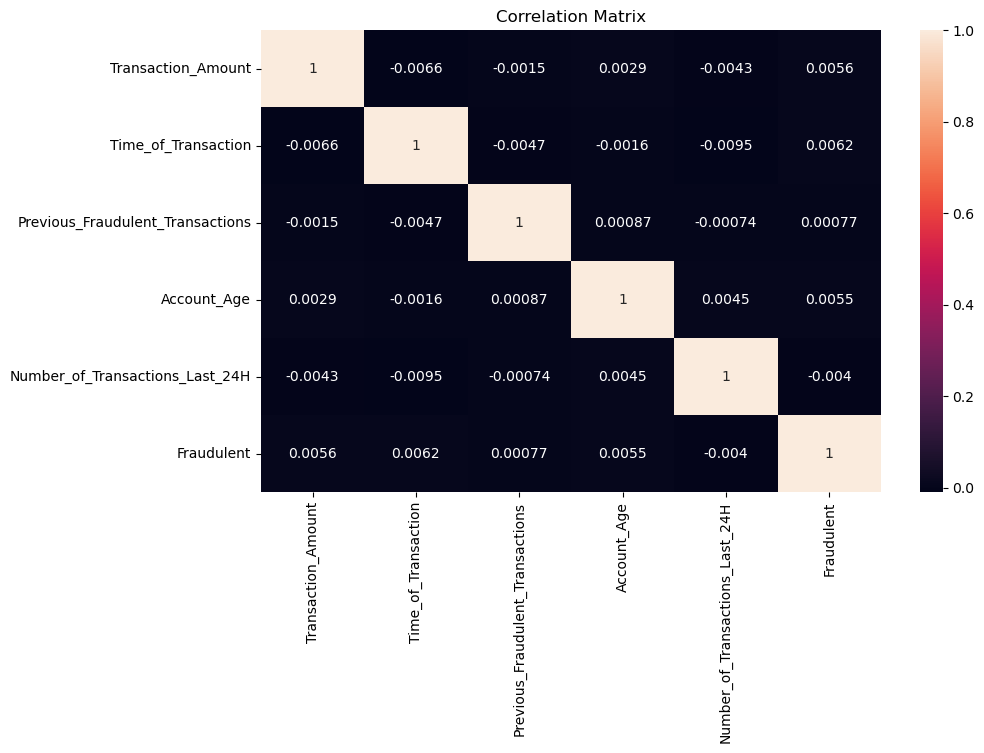

In [85]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [95]:
df.to_csv("fraud_cleaned_dataset.csv", index=False)